In [54]:
import pandas as pd
import yfinance as yf
import numpy as np
import pandas_datareader.data as web
import datetime
import os
import matplotlib.pyplot as plt
import plotly

#### 0.함수생성

In [55]:
#실현변동성 함수
def realized_volatility(x):
    return np.sqrt((x**2).sum())

#특이값 탐지 함수
def identify_outliers(row, n_sigmas=3):
    x = row['simple_rtn']
    mu = row['mean']
    sigma = row['std']

    if (x > mu + n_sigmas * sigma) or (x < mu - n_sigmas * sigma):
        return 1
    else:
        return 0

#### 1.yahoo파이넌스 데이터 다운로드

In [64]:
df = yf.download(['AAPL'], start='2000-01-01', end='2010-12-31',auto_adjust=False, progress=False)
df.columns = df.columns.droplevel(1)  #header(Ticker) 삭제

#조정종가만 추출
df=df.loc[:,['Adj Close']]
df.rename (columns={'Adj Close':'adj_close'}, inplace=True)

print(df.head())

Price       adj_close
Date                 
2000-01-03   0.837002
2000-01-04   0.766435
2000-01-05   0.777650
2000-01-06   0.710353
2000-01-07   0.744002


#### 2.미국 소비자물가지수(CPI) 다운로드

In [65]:
start = datetime.datetime(2000, 1, 1)
end = datetime.datetime(2010, 12, 31)

cpi = web.DataReader('CPIAUCSL', 'fred', start, end)
cpi.rename(columns={'CPIAUCSL':'cpi'}, inplace=True)

# CPI는 월별 데이터이므로 먼저 변화율 계산
cpi['inflation_rate'] = cpi.cpi.pct_change()

# 월별CPI를 일별CPI로 변경
cpi = cpi.reindex(df.index, method='ffill')

print(cpi.head())

              cpi  inflation_rate
Date                             
2000-01-03  169.3             NaN
2000-01-04  169.3             NaN
2000-01-05  169.3             NaN
2000-01-06  169.3             NaN
2000-01-07  169.3             NaN


#### 3.단순 수익률,로그 수익률,인플레이션 조정 수익률 생성

In [66]:
df = df.join(cpi)

df['simple_rtn']=df.adj_close.pct_change()                 #단순 수익률
df['log_rtn']=np.log(df.adj_close/df.adj_close.shift(1))   #로그 수익률
df['real_rtn']=(df.simple_rtn + 1) / (df.inflation_rate + 1) -1 #실제수익률

print(df.head())

            adj_close    cpi  inflation_rate  simple_rtn   log_rtn  real_rtn
Date                                                                        
2000-01-03   0.837002  169.3             NaN         NaN       NaN       NaN
2000-01-04   0.766435  169.3             NaN   -0.084310 -0.088077       NaN
2000-01-05   0.777650  169.3             NaN    0.014633  0.014527       NaN
2000-01-06   0.710353  169.3             NaN   -0.086538 -0.090514       NaN
2000-01-07   0.744002  169.3             NaN    0.047369  0.046281       NaN


#### 4.실현변동 계산

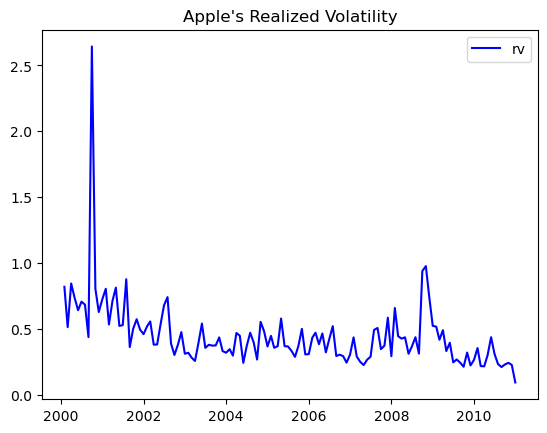

In [67]:
df_rv= df.groupby(pd.Grouper(freq='ME')).apply(realized_volatility)
df_rv.rename (columns={'log_rtn':'rv'}, inplace=True)

df_rv.rv = df_rv.rv * np.sqrt(12)

fig, ax = plt.subplots()

ax.plot(df_rv.index, df_rv.rv, color='blue', label='rv')
ax.set_title("Apple's Realized Volatility")
ax.legend(loc='upper right')

#### 5.특이값 식별

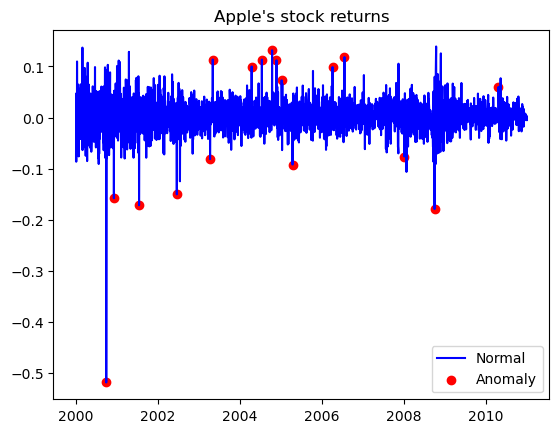

In [68]:
# 1.롤링 평균, 표준편차계산
df_rolling=df[['simple_rtn']].rolling(window=21).agg(['mean', 'std'])
df_rolling.columns = df_rolling.columns.droplevel()

# 2.롱링 척도 join
df_outliers = df.join(df_rolling)

# 3. 이상값 여부 체크
df_outliers['outlier'] = df_outliers.apply(identify_outliers,axis=1)

# 4. 이상값만 추출
outliers = df_outliers.loc[df_outliers['outlier'] == 1,['simple_rtn']]

fig, ax = plt.subplots()

ax.plot(df_outliers.index, df_outliers.simple_rtn, color='blue', label='Normal')
ax.scatter(outliers.index, outliers.simple_rtn, color='red', label='Anomaly')
ax.set_title("Apple's stock returns")
ax.legend(loc='lower right')

### 마이크로소프트 시계열 데이터 시각화

In [9]:
df = yf.download(['MSFT'], start='1980-01-01', end='2020-12-31',auto_adjust=False, progress=False)
df.columns = df.columns.droplevel(1)  #header(Ticker) 삭제

#조정종가만 추출
df=df.loc[:,['Adj Close']]
df.rename (columns={'Adj Close':'adj_close'}, inplace=True)

print(df.head())

Price       adj_close
Date                 
1986-03-13   0.059014
1986-03-14   0.061122
1986-03-17   0.062176
1986-03-18   0.060595
1986-03-19   0.059541


In [10]:
start = datetime.datetime(1980, 1, 1)
end = datetime.datetime(2020, 12, 31)

cpi = web.DataReader('CPIAUCSL', 'fred', start, end)
cpi.rename(columns={'CPIAUCSL':'cpi'}, inplace=True)

# CPI는 월별 데이터이므로 먼저 변화율 계산
cpi['inflation_rate'] = cpi.cpi.pct_change()

# 월별CPI를 일별CPI로 변경
cpi = cpi.reindex(df.index, method='ffill')

print(cpi.head())

              cpi  inflation_rate
Date                             
1986-03-13  109.1       -0.005469
1986-03-14  109.1       -0.005469
1986-03-17  109.1       -0.005469
1986-03-18  109.1       -0.005469
1986-03-19  109.1       -0.005469


In [11]:
df = df.join(cpi)

df['simple_rtn']=df.adj_close.pct_change()                 #단순 수익률
df['log_rtn']=np.log(df.adj_close/df.adj_close.shift(1))   #로그 수익률
df['real_rtn']=(df.simple_rtn + 1) / (df.inflation_rate + 1) -1 #실제수익률

print(df.head())

            adj_close    cpi  inflation_rate  simple_rtn   log_rtn  real_rtn
Date                                                                        
1986-03-13   0.059014  109.1       -0.005469         NaN       NaN       NaN
1986-03-14   0.061122  109.1       -0.005469    0.035712  0.035089  0.041408
1986-03-17   0.062176  109.1       -0.005469    0.017249  0.017102  0.022844
1986-03-18   0.060595  109.1       -0.005469   -0.025431 -0.025760 -0.020071
1986-03-19   0.059541  109.1       -0.005469   -0.017391 -0.017544 -0.011987


[Text(0.5, 0, 'Date'), Text(0, 0.5, 'Log returns ($)')]

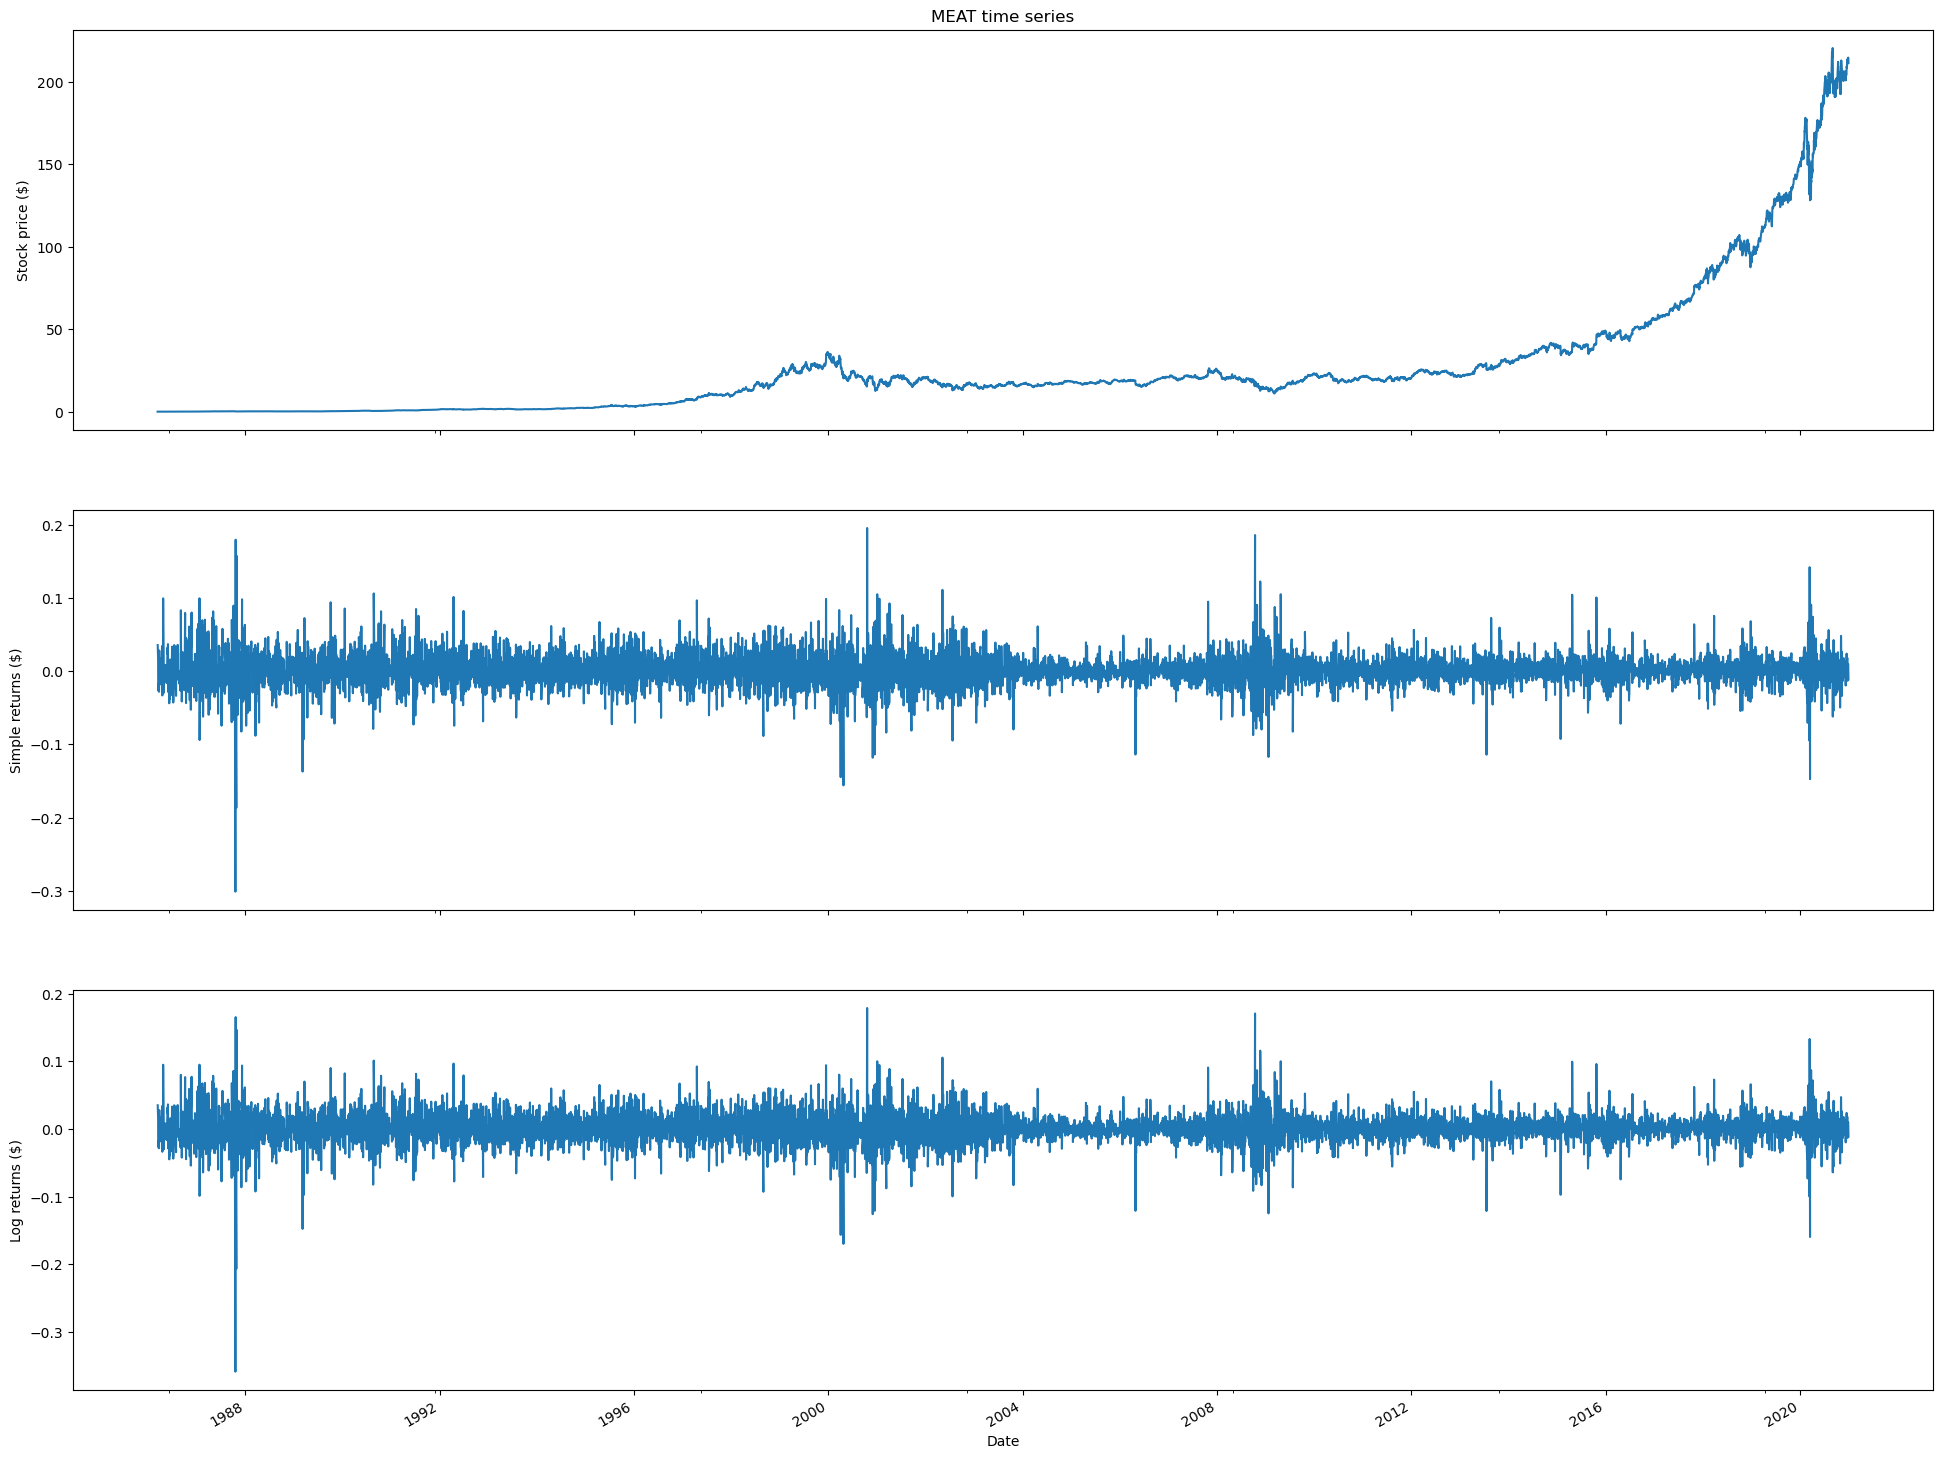

In [115]:
#df_rv= df.groupby(pd.Grouper(freq='M')).apply(realized_volatility)
#df_rv.rename (columns={'log_rtn':'rv'}, inplace=True)

#df_rv.rv = df_rv.rv * np.sqrt(12)

fig, ax = plt.subplots(3,1, figsize=(24, 20),sharex=True)
df.adj_close.plot(ax=ax[0])
ax[0].set(title='MEAT time series', ylabel= 'Stock price ($)')

df.simple_rtn.plot(ax=ax[1])
ax[1].set(ylabel= 'Simple returns ($)')

df.log_rtn.plot(ax=ax[2])
ax[2].set(xlabel='Date', ylabel= 'Log returns ($)')